In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, skew

In [2]:
pwd

'D:\\dspython\\PY92SA09L2'

#  Quick View

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
data = pd.read_csv('AmesHousing.csv')
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
data.columns = data.columns.str.replace(' ','')
data = data.drop(columns = 'PID').rename(columns = {'Order':'Id'})
data.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [6]:
data.shape

(2930, 81)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2930 non-null   int64  
 1   MSSubClass     2930 non-null   int64  
 2   MSZoning       2930 non-null   object 
 3   LotFrontage    2440 non-null   float64
 4   LotArea        2930 non-null   int64  
 5   Street         2930 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2930 non-null   object 
 8   LandContour    2930 non-null   object 
 9   Utilities      2930 non-null   object 
 10  LotConfig      2930 non-null   object 
 11  LandSlope      2930 non-null   object 
 12  Neighborhood   2930 non-null   object 
 13  Condition1     2930 non-null   object 
 14  Condition2     2930 non-null   object 
 15  BldgType       2930 non-null   object 
 16  HouseStyle     2930 non-null   object 
 17  OverallQual    2930 non-null   int64  
 18  OverallC

In [8]:
data['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

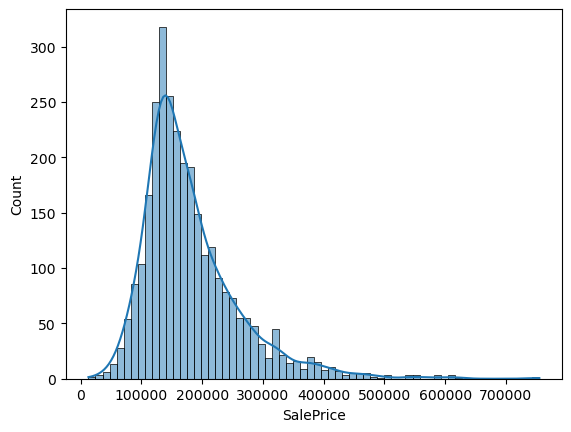

In [9]:
sns.histplot(data['SalePrice'],kde =True)

In [10]:
#Độ lệch và độ nhọn
print('Skewness of SalePrice:',data['SalePrice'].skew())
print('Kurtosis of SalePrice:',data['SalePrice'].kurt())

Skewness of SalePrice: 1.7435000757376466
Kurtosis of SalePrice: 5.118899951130896


In [11]:
data2 = data.copy()

<Axes: xlabel='SalePrice', ylabel='Count'>

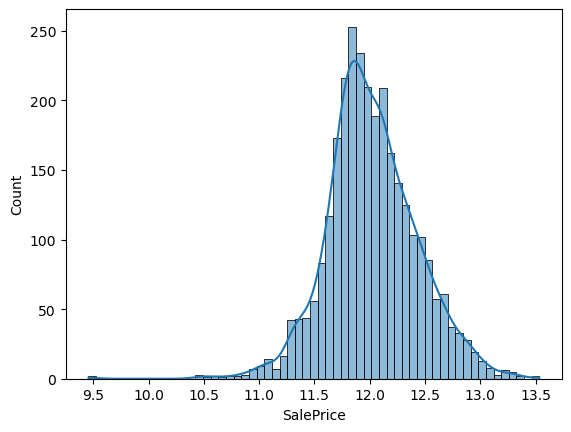

In [12]:
data2['SalePrice'] = np.log1p(data2['SalePrice'])
sns.histplot(data2['SalePrice'],kde=True)

In [13]:
print('Skewness of SalePrice:',data2['SalePrice'].skew())
print('Kurtosis of SalePrice:',data2['SalePrice'].kurt())

Skewness of SalePrice: -0.014772659537224368
Kurtosis of SalePrice: 1.5138180928006526


# Relationship

In [14]:
cols = data2.select_dtypes(include=['int64', 'float64']).corr()['SalePrice']
strongestcorr = cols[abs(cols) >0.5]
print(strongestcorr)

OverallQual      0.825645
YearBuilt        0.615485
YearRemod/Add    0.586153
TotalBsmtSF      0.625099
1stFlrSF         0.602629
GrLivArea        0.695863
FullBath         0.577335
GarageYrBlt      0.580502
GarageCars       0.675318
GarageArea       0.651132
SalePrice        1.000000
Name: SalePrice, dtype: float64


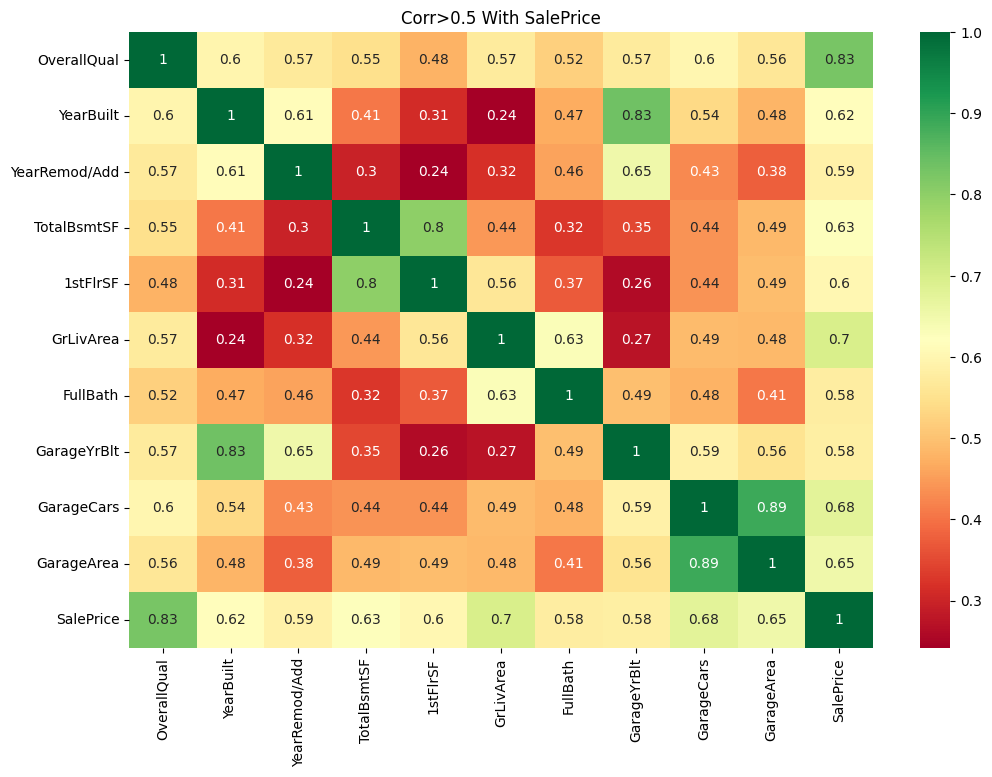

In [130]:
plt.figure(figsize=(12, 8))
sns.heatmap(data2[strongestcorr.index].corr(),annot=True,cmap="RdYlGn")
plt.title("Corr>0.5 With SalePrice")
plt.show()

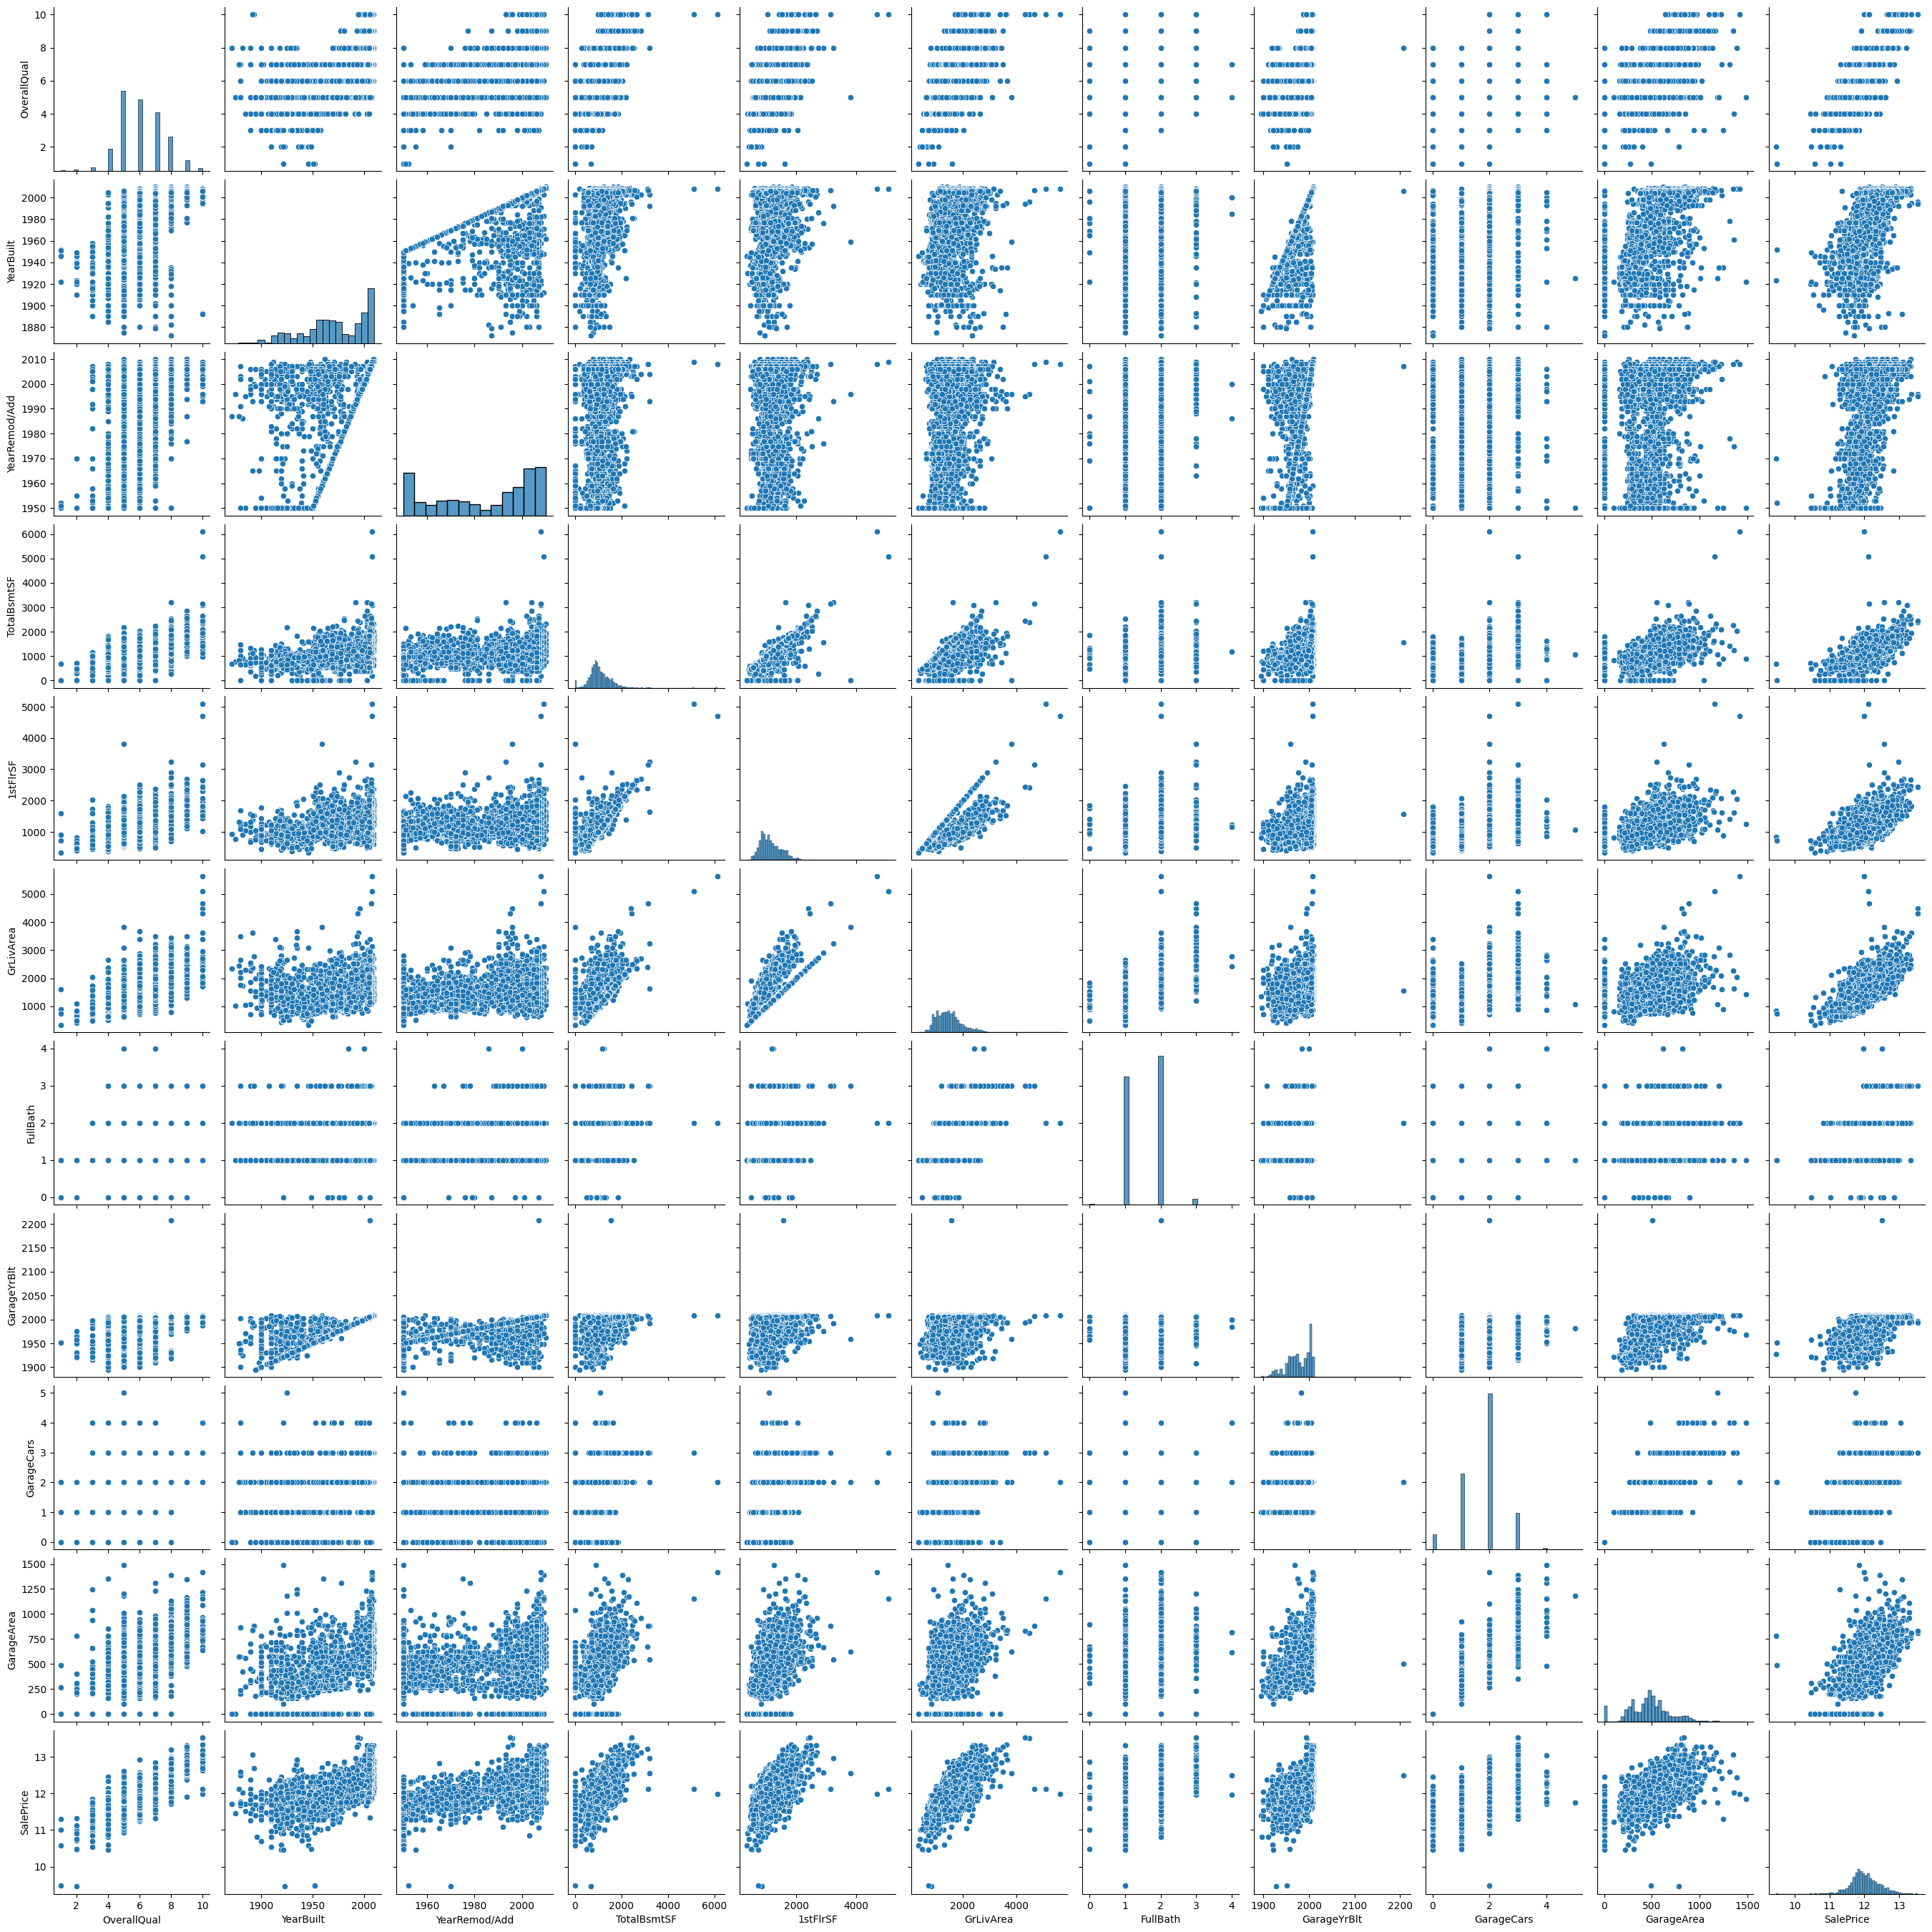

In [131]:
cols = ['OverallQual', 'YearBuilt', 'YearRemod/Add', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'SalePrice']
sns.pairplot(data2[cols])

In [132]:
x = ['OverallQual', 'YearBuilt', 'YearRemod/Add', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'SalePrice']
for cols in x:
    cols1 = data2.select_dtypes(include=['int64', 'float64']).corr()[cols]
    cols1 = cols1[abs(cols1) > 0.5]
    print(f'{cols}',cols1,sep = '\n')

OverallQual
OverallQual      1.000000
YearBuilt        0.597027
YearRemod/Add    0.569609
TotalBsmtSF      0.547294
GrLivArea        0.570556
FullBath         0.522263
GarageYrBlt      0.570569
GarageCars       0.599545
GarageArea       0.563503
SalePrice        0.825645
Name: OverallQual, dtype: float64
YearBuilt
OverallQual      0.597027
YearBuilt        1.000000
YearRemod/Add    0.612095
GarageYrBlt      0.834849
GarageCars       0.537443
SalePrice        0.615485
Name: YearBuilt, dtype: float64
YearRemod/Add
OverallQual      0.569609
YearBuilt        0.612095
YearRemod/Add    1.000000
GarageYrBlt      0.652310
SalePrice        0.586153
Name: YearRemod/Add, dtype: float64
TotalBsmtSF
OverallQual    0.547294
BsmtFinSF1     0.536547
TotalBsmtSF    1.000000
1stFlrSF       0.800720
SalePrice      0.625099
Name: TotalBsmtSF, dtype: float64
1stFlrSF
TotalBsmtSF    0.800720
1stFlrSF       1.000000
GrLivArea      0.562166
SalePrice      0.602629
Name: 1stFlrSF, dtype: float64
GrLivArea
Over

In [133]:
# OverallQual có tương quan với:
#YearBuilt(0.5970),YearRemod/Add(0.5696),TotalBsmtSF(0.5473),GrLivArea(0.5706),FullBath(0.5223),GarageYrBlt(0.5706),GarageCars(0.5995),GarageArea(0.5635),SalePrice(0.8256)

# YearBuilt có tương quan với:
# OverallQual(0.5970),YearRemod/Add(0.6121),GarageYrBlt(0.8348),GarageCars(0.5374),SalePrice(0.6155)

# YearRemod/Add có tương quan với:
# OverallQual(0.5696),YearBuilt(0.6121),GarageYrBlt(0.6523),SalePrice(0.5862)

# TotalBsmtSF có tương quan với:
# OverallQual(0.5473),BsmtFinSF1(0.5365),1stFlrSF(0.8007),SalePrice(0.6251)

# 1stFlrSF có tương quan với:
# TotalBsmtSF(0.8007),GrLivArea(0.5622),SalePrice(0.6026)

# GrLivArea có tương quan với:
# OverallQual(0.5706),1stFlrSF(0.5622),2ndFlrSF(0.6553),FullBath(0.6303),BedroomAbvGr(0.5168),TotRmsAbvGrd(0.8078),SalePrice(0.6959)

# FullBath có tương quan với:
# OverallQual(0.5223),GrLivArea(0.6303),TotRmsAbvGrd(0.5286),SalePrice(0.5773)

# GarageYrBlt có tương quan với:
# OverallQual(0.5706),YearBuilt(0.8348),YearRemod/Add(0.6523),GarageCars(0.5867),GarageArea(0.5550),SalePrice(0.5805)

# GarageCars có tương quan với:
# OverallQual(0.5995),YearBuilt(0.5374),GarageYrBlt(0.5867),GarageArea(0.8897),SalePrice(0.6753)

# GarageArea có tương quan với:
# OverallQual(0.5635),GarageYrBlt(0.5550),GarageCars(0.8897),SalePrice(0.6511)

# Null Investigation

In [15]:
data2.shape

(2930, 81)

In [16]:
pd.DataFrame(data2.isnull().sum()).T

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,0,0,490,0,0,2732,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1775,23,0,0,0,80,80,83,80,1,81,1,1,1,0,0,0,1,0,0,0,0,2,2,0,0,0,0,0,0,0,0,1422,157,159,159,1,1,159,159,0,0,0,0,0,0,0,2917,2358,2824,0,0,0,0,0,0


In [17]:
null_col=data2.isnull().sum()
null_col = null_col[null_col>0].sort_values(ascending = False)
miss = null_col.index.to_list()
missing = pd.DataFrame({'count':null_col,'percent':null_col/data2.shape[0]*100,'Type':data2[miss].dtypes})
missing

,count,percent,Type
PoolQC,2917,99.556314,object
MiscFeature,2824,96.382253,object
Alley,2732,93.242321,object
Fence,2358,80.477816,object
MasVnrType,1775,60.580205,object
FireplaceQu,1422,48.532423,object
LotFrontage,490,16.723549,float64
GarageQual,159,5.426621,object
GarageCond,159,5.426621,object
GarageYrBlt,159,5.426621,float64


In [18]:
# Cleaning data

In [19]:
data2.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,12.278398
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,11.561725
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,12.055256
3,4,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,12.404928
4,5,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,12.154258


In [20]:
# #Kiểm tra những cột nhiều null nhất là những cột object xử lý chúng trc
# PoolQC
# MiscFeature	
# Alley
# Fence
# MasVnrType	
# FireplaceQu	
#trong các cột chứa nan thì có cột MasVnrType và cột MasVnrArea	có mối quan hệ nên xử lý cột MasVnrType sau

In [21]:
x =  ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu']

for col in x:
    print(f"\n===== {col} =====")
    print(data2[col].unique())


===== PoolQC =====
[nan 'Ex' 'Gd' 'TA' 'Fa']

===== MiscFeature =====
[nan 'Gar2' 'Shed' 'Othr' 'Elev' 'TenC']

===== Alley =====
[nan 'Pave' 'Grvl']

===== Fence =====
[nan 'MnPrv' 'GdPrv' 'GdWo' 'MnWw']

===== MasVnrType =====
['Stone' nan 'BrkFace' 'BrkCmn' 'CBlock']

===== FireplaceQu =====
['Gd' nan 'TA' 'Po' 'Ex' 'Fa']


In [22]:
col =  ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu']
data2[col] = data2[col].fillna('None')

In [23]:
fill = missing[missing['percent']<=6].index.to_list()
data2[fill].dtypes

GarageQual       object
GarageCond       object
GarageYrBlt     float64
GarageFinish     object
GarageType       object
BsmtExposure     object
BsmtFinType2     object
BsmtCond         object
BsmtQual         object
BsmtFinType1     object
MasVnrArea      float64
BsmtFullBath    float64
BsmtHalfBath    float64
BsmtFinSF1      float64
BsmtFinSF2      float64
Electrical       object
TotalBsmtSF     float64
BsmtUnfSF       float64
GarageArea      float64
GarageCars      float64
dtype: object

In [46]:
num_fill = data2[fill].select_dtypes(['float64']).columns
cate_fill = data2[fill].select_dtypes(['object']).columns

In [47]:
 # Basement :BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath
# Garage :GarageArea ↔ GarageCars
#Cột không tương quan missing:GarageYrBlt, MasVnrArea

In [48]:
# Dữ liệu bị thiếu một cách không ngẫu nhiên, nếu loại bỏ (các dòng/cột có dữ liệu thiếu) sẽ tạo ra sai lệch cho mô hình."

In [49]:
data2[cate_fill] = data2[cate_fill].fillna(data2[cate_fill].mode().iloc[0])

In [50]:
num_fill

Index(['GarageYrBlt', 'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath',
       'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF', 'BsmtUnfSF', 'GarageArea',
       'GarageCars'],
      dtype='object')

In [42]:
cols = data2.select_dtypes(include=['int64', 'float64']).corr()['LotFrontage']
strongcorr1 = cols[abs(cols) >0.5]
print(strongcorr1)

LotFrontage    1.0
Name: LotFrontage, dtype: float64


In [43]:
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer()
num_fill = num_fill.to_list()
num_fill.append('LotFrontage')
num_fill

['GarageYrBlt',
 'MasVnrArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'TotalBsmtSF',
 'BsmtUnfSF',
 'GarageArea',
 'GarageCars',
 'LotFrontage']

In [29]:
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer()
num_fill = num_fill.to_list()
num_fill.append('LotFrontage')
for c in num_fill:
    data2[c] = knn_imputer.fit_transform(data2[[c]])

In [30]:
data2[num_fill].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GarageYrBlt   2930 non-null   float64
 1   MasVnrArea    2930 non-null   float64
 2   BsmtFullBath  2930 non-null   float64
 3   BsmtHalfBath  2930 non-null   float64
 4   BsmtFinSF1    2930 non-null   float64
 5   BsmtFinSF2    2930 non-null   float64
 6   TotalBsmtSF   2930 non-null   float64
 7   BsmtUnfSF     2930 non-null   float64
 8   GarageArea    2930 non-null   float64
 9   GarageCars    2930 non-null   float64
 10  LotFrontage   2930 non-null   float64
dtypes: float64(11)
memory usage: 251.9 KB


In [ ]:
data2[cate_fill].info()

In [ ]:
#còn null của MasVnrType
data2.isnull().sum().sum()

In [ ]:
# data2.loc[data2['MasVnrArea'] == 0, 'MasVnrType'] = 'None'
# mode1 = data2['MasVnrType'].mode()[0]
# data2['MasVnrType'] = data2['MasVnrType'].fillna(mode1)
# data2.isnull().sum().sum()

In [ ]:
# Cleaning Data

In [ ]:
data2 = data2.rename(columns={'YearRemod/Add':'YearRemodAdd'})
data2

## Data Type constraints

In [ ]:
data2.info()

In [ ]:
data2.select_dtypes('object').head()

In [ ]:
# check

In [ ]:
data2.select_dtypes('object').nunique()

In [ ]:
data2.select_dtypes('object').head()

In [ ]:
#Kiểm tra object
x = data2.select_dtypes(include = 'object').columns
for col in x:
    print(f"\n===== {col} =====")
    print(data2[col].unique())

In [ ]:
x = data2.select_dtypes(include = 'object').columns
for i in x:
    data2[i] = data2[i].astype('category')
data2.info()

In [ ]:
data2.head()

In [ ]:
# Kiểm tra cột dạng số liên tục

In [ ]:
x =['MSSubClass','MoSold','YrSold','OverallQual','OverallCond','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars']
for col in x:
    print(data[col].value_counts().sort_index())

In [ ]:
data2['MSSubClass'] = data2['MSSubClass'].apply(str).astype('category')
data2['YrSold'] = data2['YrSold'].apply(str).astype('category')
data2['MoSold'] = data2['MoSold'].apply(str).astype('category')

## Check duplicate

In [ ]:
data2.duplicated().sum()

## Lowercase & strip

In [ ]:
cols = data2.select_dtypes('category').columns
cols

In [ ]:
for col in cols:
    data2[col] = data2[col].str.lower().str.strip()
    data2[col] = data2[col].astype('category')
data2['PoolQC'].value_counts()

In [ ]:
data2.nunique()

## Data Range constraints

In [ ]:
data2.describe()

### Univariate outliers analysis

In [ ]:
data2.select_dtypes(exclude = 'category').columns

In [ ]:
df_num = data2.select_dtypes(include=['int64','float64']).drop(
    columns=['Id']
)

# Số subplot
ncols = 3
nrows = int(np.ceil(df_num.shape[1] / ncols))

# Tạo figure lớn
fig = plt.figure(figsize=(18, 6*nrows))

for i, col in enumerate(df_num.columns):
    ax = fig.add_subplot(nrows, ncols, i + 1)
    
    sns.boxplot(x=df_num[col], ax=ax, color='skyblue')
    ax.set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

### Multivariate outlier analysis

In [ ]:
data2.head()

In [ ]:
num_col = data2.select_dtypes(['int64','float64'])

In [ ]:
def doutlier(d, whisker_width=1.5):
    q25 = d.quantile(0.25)
    q75 = d.quantile(0.75)
    iqr = q75 - q25
    return d[(d > q75+whisker_width*iqr) | (d < q25-whisker_width*iqr)]

In [ ]:
doutlier(num_col, whisker_width=1.5).count().sort_values(ascending=False)

In [ ]:
#Nan các hàng ko phải outlier
outlier = doutlier(num_col, whisker_width=1.5).dropna(how='all')
outlier

In [ ]:
#Các hàng saleprice bị outlier có liên quan đến các cột khác cũng bị outlier
outprice = outlier[outlier['SalePrice'].notnull()]
outprice.head()

In [ ]:
#In ra số lg outlier mỗi cột tại outlier của cột saleprice
outprice.count().sort_values(ascending=False)

In [ ]:
x = strongestcorr.index
x = x.str.replace('YearRemod/Add', 'YearRemodAdd')
x

In [ ]:
#Số lượng outlier của các cột tương quan mạnh với saleprice
doutlier(num_col, whisker_width=1.5)[x].count().sort_values(ascending=False)

In [ ]:
plt.figure(figsize=(8,8))
g = sns.heatmap(outlier[x].corr(),annot=True,cmap="RdYlGn")

In [ ]:
# many outliers in dataset, but outliers of key feature having high corr with outliers of target variable
# => log scale to make sure not missing data

# Feature Engineering

## Create new feature

In [ ]:
data3 = data2.copy()

In [ ]:
data2=data3.copy()

In [ ]:
#Tong dien tich toa nha
data2['ToTalSF'] = data2['TotalBsmtSF'] + data2['1stFlrSF'] + data2['2ndFlrSF']
data2.head()

In [ ]:
data2[data2['HalfBath'] == 1].head(2)

In [ ]:
#Tong so Wc
#half bath là chỉ đc 1/2 cái WC-> số halfbath*1/2
data2['TotalBath'] = data2['BsmtFullBath'] + data2['FullBath'] + 1/2*data2['HalfBath'] + 1/2*data2['BsmtHalfBath']
data2['TotalBath'].head()

In [ ]:
#Tổng diện tích hiên nhà
data2['TotalPorchSF'] = (data2['OpenPorchSF'] + data2['3SsnPorch'] + data2['EnclosedPorch'] + data2['ScreenPorch'] + data2['WoodDeckSF'])

In [ ]:
#Diện tích trung bình 
data2["SqFtPerRoom"] = data2["GrLivArea"] / (data2["TotRmsAbvGrd"] +  data2["FullBath"] + data2["HalfBath"] +data2["KitchenAbvGr"])
data2['SqFtPerRoom'].describe()

In [ ]:
data2.head()

In [ ]:
#Tổng thể chất lượng nhà
data2['TotalHomeQuality'] = data2['OverallQual'] + data2['OverallCond']
data2['TotalHomeQuality'].describe()

In [ ]:
data2["HighQualSF"] = data2["1stFlrSF"] + data2["2ndFlrSF"]
data2["HighQualSF"].describe()

In [ ]:
#Tong diện tích tầng hầm đã hoàn thiện
data2['TotalFinishBsmtSF'] = data2['BsmtFinSF1'] + data2['BsmtFinSF2']
#check lại xem có bằng tổng diện tích tầng hầm k
check = (data2['TotalBsmtSF'] != (data2['TotalFinishBsmtSF']  +  data2['BsmtUnfSF']))
data2[check]

In [ ]:
data2['HouseStyle'].value_counts()

In [ ]:
data2['HasPool'] = (data2['PoolArea'] > 0).astype(int)
data2['HasFỉreplace'] = (data2['Fireplaces'] > 0).astype(int)
data2['HasGarage'] = (data2['GarageArea'] > 0).astype(int)
data2['HasHouseLevel2'] = (data2['2ndFlrSF'] > 0).astype(int)
data2['HasBmt'] = (data2['TotalBsmtSF'] > 0).astype(int)

In [ ]:
for x in ['HasPool','HasFỉreplace','HasGarage','HasHouseLevel2','HasBmt']:
    data2[x]= data2[x].astype('category')

In [ ]:
data2.head()

## Fix skew data

In [ ]:
from scipy.stats import skew

In [ ]:
data4 = data2.copy()

In [ ]:
data2=data4.copy()

In [ ]:
data2.info()

In [ ]:
num_cols = data2.select_dtypes(include=['int64','float64']).columns
skew_val = data2[num_cols].skew().sort_values(ascending = False)
for col,skew in skew_val.items():
    print(f'{col:<20}  Skew:{skew}')

In [ ]:
x = skew_val[abs(skew_val) > 0.5].index
x

In [ ]:
df_num = data2[x]

ncols = 4
nrows = int(np.ceil(df_num.shape[1] / ncols))

plt.figure(figsize=(17, 5 * nrows))

for i, col in enumerate(df_num.columns):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.histplot(data2[col], kde=True, color='blue')
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [ ]:
y = x.to_list()
data2[x].describe()

In [ ]:
for i in x:
    data2[i] = np.log1p(data2[i])

In [ ]:
df_num = data2[x]

ncols = 4
nrows = int(np.ceil(df_num.shape[1] / ncols))

plt.figure(figsize=(17, 5 * nrows))

for i, col in enumerate(df_num.columns):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.histplot(data2[col], kde=True, color='blue')
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## Encoding category variables

In [ ]:
x = data2.select_dtypes('category').columns.tolist()

for col in x:
    print(f"\n===== {col} =====")
    print(data2[col].unique())

In [ ]:
# #Cach 1
# ordinal_maps = {
#     'ExterQual': {'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},
#     'ExterCond': {'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},

#     'BsmtQual':  {'none':0, 'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},
#     'BsmtCond':  {'none':0, 'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},
#     'BsmtExposure': {'none':0, 'no':1, 'mn':2, 'av':3, 'gd':4},

#     'BsmtFinType1': {'none':0, 'unf':1, 'lwq':2, 'rec':3, 'blq':4, 'alq':5, 'glq':6},
#     'BsmtFinType2': {'none':0, 'unf':1, 'lwq':2, 'rec':3, 'blq':4, 'alq':5, 'glq':6},

#     'FireplaceQu': {'none':0, 'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},

#     'GarageQual':  {'none':0, 'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},
#     'GarageCond':  {'none':0, 'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},
#     'GarageFinish': {'none':0, 'unf':1, 'rfn':2, 'fin':3},

#     'KitchenQual': {'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},

#     'HeatingQC': {'po':1, 'fa':2, 'ta':3, 'gd':4, 'ex':5},

#     'Functional': {'sev':1, 'maj2':2, 'maj1':3, 'min2':4, 'min1':5, 'mod':6, 'typ':7, 'sal':0},

#     'PoolQC': {'none':0, 'fa':1, 'ta':2, 'gd':3, 'ex':4},

#     'Fence': {'none':0, 'mnww':1, 'mnprv':2, 'gdwo':3, 'gdprv':4}
# }

# for col, mapping in ordinal_maps.items():
#     data2[col] = data2[col].astype("object")      
#     data2[col] = data2[col].map(mapping)           
#     data2[col] = data2[col].fillna(0)       #fill các giá trị ko khớp nếu có thành 0       
#     data2[col] = data2[col].astype("int64")       

# data2.head()

In [ ]:
# One Hot encoding,tách nunique = n của 1 cột thành n cột 

In [ ]:
# onehot = data2.select_dtypes(include='category').columns.tolist()

# data2 = pd.get_dummies(data2, columns=onehot, drop_first=True)


In [ ]:
# bool_cols = data2.select_dtypes(include='bool').columns

# data2[bool_cols] = data2[bool_cols].astype(int)
# data2.head()

In [ ]:
def test_mean_target_encoding(train, test, target, categorical, alpha=5):
    # Calculate global mean on the train data
    global_mean = train[target].mean()
    
    # Group by the categorical feature and calculate its properties
    train_groups = train.groupby(categorical)
    category_sum = train_groups[target].sum()
    category_size = train_groups.size()
    
    # Calculate smoothed mean target statistics
    train_statistics = (category_sum + global_mean * alpha) / (category_size + alpha)
    
    # Apply statistics to the test data and fill new categories
    test_feature = test[categorical].map(train_statistics).fillna(global_mean)
    return test_feature.values

In [ ]:
from sklearn.model_selection import KFold
def train_mean_target_encoding(train, target, categorical, alpha=5):
    # Create 5-fold cross-validation
    kf = KFold(n_splits=5, random_state=123, shuffle=True)
    train_feature = pd.Series(index=train.index)
    
    # For each folds split
    for train_index, test_index in kf.split(train):
        cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]
      
        # Calculate out-of-fold statistics and apply to cv_test
        cv_test_feature = test_mean_target_encoding(cv_train, cv_test, target, categorical, alpha)
        
        # Save new feature for this particular fold
        train_feature.iloc[test_index] = cv_test_feature       
    return train_feature.values

In [ ]:
cate = data2.select_dtypes('category').columns
data2[cate].head()

In [ ]:
data2.shape

In [ ]:
df = data2.copy()

In [ ]:
for c in df[cate].columns:
    df[c] = df[c].astype('object')
    train_feature = train_mean_target_encoding(df, 'SalePrice', c, alpha=5)
    df[c] = train_feature
df.head()

# Modeling Selection

In [ ]:
# import shap
import xgboost as xgb
from catboost import Pool
from sklearn.svm import SVR
from catboost import CatBoostRegressor
# from lightgbm import LGBMRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from mlxtend.regressor import StackingRegressor
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor, plot_importance

In [ ]:
# !pip install xgboost
# !pip install catboost
# !pip install mlxtend

In [ ]:
corr = df.corr()['SalePrice'].abs().sort_values(ascending=False)
corr.head(20)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns='SalePrice'),df['SalePrice'],test_size =0.2,shuffle=True,random_state = 42)

In [ ]:
x_train.shape

In [ ]:
def ham(y_test, y_pred):
    print("R2 =", r2_score(y_test, y_pred))
    print("MAE =", mean_absolute_error(y_test, y_pred))
    print("MSE =", mean_squared_error(y_test, y_pred))
    print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
def ham1(y_test, y_pred):
    R2 = r2_score(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    MSE = mean_squared_error(y_test, y_pred)
    return R2, MAE, MSE, RMSE

In [ ]:
results =[]

<h1 style="text-align:center;">XGBoost</h1>

In [ ]:
param_grid = {
    "n_estimators":  [300, 500, 800],
    "max_depth":     [3, 4],
    "learning_rate": [0.1, 0.05],
    "subsample":     [0.8],
    "colsample_bytree": [0.8],
    "reg_alpha":     [0.0, 0.1],
    "reg_lambda":    [1.0, 2.0],
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
)
#cross validation tập train

gsearch = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  
    cv=2,
    n_jobs=-1,
    verbose=1,
)

gsearch.fit(x_train, y_train)

print("Best params:", gsearch.best_params_)
print("Best CV RMSE:", -gsearch.best_score_)

In [ ]:
best_params = gsearch.best_params_

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    **best_params     
)

xgb.fit(x_train, y_train)
y_pred1 = xgb.predict(x_test)

In [ ]:
ham(y_test,y_pred1)

In [ ]:
R2, MAE, MSE, RMSE = ham1(y_test, y_pred1)
results.append(["XGBoost", R2, MAE, MSE, RMSE])

In [ ]:
importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)

<h1 style="text-align:center;">Linear Regression</h1>

In [ ]:
folds = KFold(n_splits=10, shuffle=True, random_state=42)
hyper_params = [{'n_features_to_select': list(range(1, 21))}]
model = LinearRegression()

rfe = RFE(estimator=model)

model_cv = GridSearchCV(
    estimator=rfe,
    param_grid=hyper_params,
    scoring='neg_mean_squared_error',
    cv=folds,
    return_train_score=True,
    verbose=1,
)

model_cv.fit(x_train, y_train)

In [ ]:
cv_result = pd.DataFrame(model_cv.cv_results_)
cv_result['mean_train_RMSE'] = np.sqrt(-cv_result['mean_train_score'])
cv_result['mean_test_RMSE']  = np.sqrt(-cv_result['mean_test_score'])

cv_result[['param_n_features_to_select','mean_train_RMSE','mean_test_RMSE']]

In [ ]:
best_rfe = model_cv.best_estimator_
best_rfe.support_       # mảng True/False độ dài = n_features
best_rfe.ranking_ 

In [ ]:
selected_features = x_train.columns[best_rfe.support_]
print(selected_features)

In [ ]:
plt.figure(figsize=(12,8))
sns.lineplot(x = cv_result['param_n_features_to_select'],y = cv_result['mean_train_RMSE'],marker = 'o')
sns.lineplot(x = cv_result['param_n_features_to_select'],y = cv_result['mean_test_RMSE'],marker = 'o')
plt.legend(['train_RMSE','test_RMSE'],loc='best')
plt.title('Optimal features(RMSE)')

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [ ]:
lm = LinearRegression()

rfe = RFE(lm, n_features_to_select=18)
rfe = rfe.fit(x_train, y_train)

In [ ]:
select = x_train.columns[rfe.support_]
select

In [ ]:
lm.fit(x_train[select],y_train)
y_pred2 = lm.predict(x_test[select])

In [ ]:
ham(y_test,y_pred2)

In [ ]:
R2, MAE, MSE, RMSE = ham1(y_test, y_pred2)
results.append(["LinearRegression", R2, MAE, MSE, RMSE])

In [ ]:
df.shape

<h1 style="text-align:center;">RandomForest</h1>

In [ ]:
def randomforest(x):
    max_feature1 =int(np.sqrt(x))

    forest = RandomForestRegressor(
     max_features = max_feature1,
     max_depth=int(np.log2(x)),
     n_estimators=x-max_feature1+1,
     max_samples=0.8,
     random_state=42
    )
    return forest

In [ ]:
col = x_train.shape[1]
forest = randomforest(col)


forest.fit(x_train,y_train)  

In [ ]:
y_pred3=forest.predict(x_test)
ham(y_test,y_pred3)

In [ ]:
R2, MAE, MSE, RMSE = ham1(y_test, y_pred3)
results.append(["Random Forest", R2, MAE, MSE, RMSE])

In [ ]:
names=x_train.columns.to_list()
importance = forest.feature_importances_
df_importance = pd.DataFrame({'Names':names,'Importance':importance})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

df_importance.reset_index(drop=True, inplace=True)
df_importance.head(20)

In [ ]:
from sklearn.feature_selection import SelectFromModel

In [ ]:
selector=SelectFromModel(forest,threshold=0.04)
selector

In [ ]:
selected= selector.get_support()
selected_feature_names = x_train.columns[selected]

print(selected_feature_names)

<h1 style="text-align:center;">GradientBoosting</h1>

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 5]
}

gb = GradientBoostingRegressor(random_state=42)
gb_cv = GridSearchCV(
    estimator=gb,
    param_grid=grid,
    cv=4,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

gb_cv.fit(x_train, y_train)

print("Best Parameters:", gb_cv.best_params_)
print("Best CV RMSE:", -gb_cv.best_score_)

In [ ]:
gb1 = GradientBoostingRegressor(learning_rate=0.05,n_estimators=500,max_depth = 3,random_state=42)
gb1.fit(x_train,y_train)

In [ ]:
y_pred4 = gb1.predict(x_test)
ham(y_test,y_pred4)

In [ ]:
R2, MAE, MSE, RMSE = ham1(y_test, y_pred4)
results.append(["GradientBoosting", R2, MAE, MSE, RMSE])

<h1 style="text-align:center;">CatBoost</h1>

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

cat = CatBoostRegressor(
    loss_function='RMSE',
    verbose=False,
    random_state=42
)

param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.01,0.03, 0.05],
    'iterations': [700, 1000]
}

grid = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    cv=4,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)

In [ ]:
cat1 = CatBoostRegressor(
    loss_function="RMSE",
    depth=6,
    iterations=1000,
    learning_rate=0.03,
    random_state=42,
    verbose=False
)

cat1.fit(x_train, y_train)

In [ ]:
y_pred5 = cat1.predict(x_test)
R2, MAE, MSE, RMSE = ham1(y_test, y_pred5)

results.append(("CatBoost", R2, MAE, MSE, RMSE))
ham(y_test,y_pred5)

<h1 style="text-align:center;">StackingRegressor</h1>

In [ ]:
from sklearn.ensemble import StackingRegressor

In [ ]:
estimators1 = [
    ('gb', model_gb),
    ('xgb', model_xgb),
    ('cat', model_cat)
]

meta = CatBoostRegressor()

stack_model = StackingRegressor(
    estimators=estimators1,
    final_estimator=meta,
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(x_train, y_train)

In [ ]:
y_pred6 = stack_model.predict(x_test)
R2, MAE, MSE, RMSE = ham1(y_test, y_pred6)

results.append(("Stacking", R2, MAE, MSE, RMSE))
ham(y_test,y_pred6)

<h1 style="text-align:center;">So sánh mô hình</h1>

In [ ]:
df = pd.DataFrame(results, columns=['Model', 'R2', 'MAE', 'MSE', 'RMSE'])

In [ ]:
plt.figure(figsize=(15, 8))
plt.bar(df['Model'], df['R2'], color='skyblue')
plt.title("So sánh R² giữa các mô hình", fontsize=16)
plt.xticks(rotation=30)
plt.show()

In [ ]:
# -------------------------
plt.figure(figsize=(15, 6))
plt.bar(df['Model'], df['RMSE'], color='salmon')
plt.title("So sánh RMSE giữa các mô hình", fontsize=16)
plt.xticks(rotation=30)
plt.show()